# Airplane Price Dataset

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor


In [3]:
path = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/airplane_price_dataset.csv"

In [4]:
path

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/airplane_price_dataset.csv'

In [5]:
df_airplane = pd.read_csv(path + "/airplane_price_dataset.csv")

In [6]:
df_airplane.head()

,Model,Üretim Yılı,Motor Sayısı,Motor Türü,Kapasite,Menzil (km),Yakıt Tüketimi (L/saat),Saatlik Bakım Maliyeti ($),Yaş,Satış Bölgesi,Fiyat ($)
0,Bombardier CRJ200,1987,2,Turbofan,50,3000,14.36,2185.43,36,Asya,1.285708e+07
1,Bombardier CRJ200,1997,2,Turbofan,50,3000,4.03,1202.08,26,Avrupa,1.391406e+07
2,Airbus A320,1988,2,Turbofan,180,6300,13.26,761.38,35,Avustralya,9.073570e+07
3,Boeing 737,2023,2,Turbofan,162,5700,14.61,592.63,0,Avustralya,1.366597e+08
4,Cessna 172,1985,1,Piston,4,1285,18.49,4245.99,38,Güney Amerika,2.037981e+05


In [7]:
column_names = [
    'Modelo',
    'Ano de produção',
    'Número de motores',
    'Tipo de motor',
    'Capacidade',
    'Autonomia (km)',
    'Consumo de combustível (L/hora)',
    'Custo de manutenção por hora ($)',
    'Idade',
    'Região de Vendas',
    'Preço ($)'
]

In [8]:
# Renomenado as colunas
df_airplane.columns = column_names

In [9]:
df_airplane.shape

(12377, 11)

In [10]:
target = "Preço ($)"

In [11]:
df_airplane.head()

,Modelo,Ano de produção,Número de motores,Tipo de motor,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Região de Vendas,Preço ($)
0,Bombardier CRJ200,1987,2,Turbofan,50,3000,14.36,2185.43,36,Asya,1.285708e+07
1,Bombardier CRJ200,1997,2,Turbofan,50,3000,4.03,1202.08,26,Avrupa,1.391406e+07
2,Airbus A320,1988,2,Turbofan,180,6300,13.26,761.38,35,Avustralya,9.073570e+07
3,Boeing 737,2023,2,Turbofan,162,5700,14.61,592.63,0,Avustralya,1.366597e+08
4,Cessna 172,1985,1,Piston,4,1285,18.49,4245.99,38,Güney Amerika,2.037981e+05


## Analisando o Target

In [12]:
df_airplane[target]

0        1.285708e+07
1        1.391406e+07
2        9.073570e+07
3        1.366597e+08
4        2.037981e+05
             ...     
12372    3.898071e+08
12373    1.593888e+07
12374    9.870994e+07
12375    3.965207e+05
12376    2.320782e+07
Name: Preço ($), Length: 12377, dtype: float64

In [13]:
df_airplane[target].describe()

count    1.237700e+04
mean     1.988336e+08
std      2.290392e+08
min      1.458148e+05
25%      1.409681e+07
50%      8.392191e+07
75%      3.843239e+08
max      9.782132e+08
Name: Preço ($), dtype: float64

<Axes: ylabel='Frequency'>

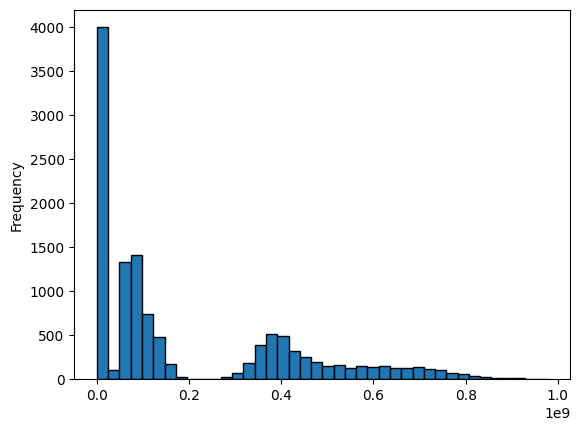

In [14]:
df_airplane[target].plot(kind="hist", bins=40, edgecolor="black")

In [15]:
# Transformando a unidade do target (de doláres para milhões de doláres)
df_airplane[target] = df_airplane[target] / 1000000

<Axes: ylabel='Frequency'>

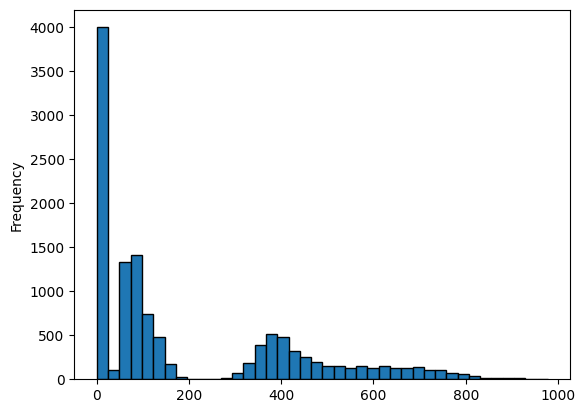

In [16]:
df_airplane[target].plot(kind="hist", bins=40, edgecolor="black")

## Separação de Dados

In [17]:
X = df_airplane.drop(target, axis=1)
y = df_airplane[target]

In [18]:
X.select_dtypes("object").describe()

,Modelo,Tipo de motor,Região de Vendas
count,12377,12377,12377
unique,6,2,6
top,Boeing 737,Turbofan,Afrika
freq,2121,10338,2171


## Preparação dos dados

In [19]:
categorical_features = ["Modelo", "Tipo de motor",	"Região de Vendas"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.preprocessing import OneHotEncoder

In [22]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[categorical_features])

X_train_categorical_columns = encoder.transform(X_train[categorical_features])
X_test_categorical_columns = encoder.transform(X_test[categorical_features])

X_train = pd.concat([X_train.drop(categorical_features, axis=1), X_train_categorical_columns], axis=1)
X_test = pd.concat([X_test.drop(categorical_features, axis=1), X_test_categorical_columns], axis=1)

In [23]:
X_train.head()

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de Vendas_Afrika,Região de Vendas_Asya,Região de Vendas_Avrupa,Região de Vendas_Avustralya,Região de Vendas_Güney Amerika,Região de Vendas_Kuzey Amerika
123,1988,2,350,14800,9.45,4777.73,35,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,1986,2,162,5700,3.43,516.27,37,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,2017,2,396,15600,13.86,4709.85,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,1982,2,180,6300,3.42,2721.65,41,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,1989,2,50,3000,6.16,1974.45,34,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Modelagem
Testando diferentes Regressores

### Árvore de Decisão

In [24]:
from sklearn.tree import DecisionTreeRegressor

In [25]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [26]:
y_pred = model.predict(X_test)

In [27]:
# Funcao para aplicar várias métricas de avaliação

def regression_report(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  mape = mean_absolute_percentage_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)

  return pd.Series({
      "MAE": mae,
      "MSE": mse,
      "RMSE": rmse,
      "MAPE": mape * 100,
      "R2": r2
  })

In [28]:
# Função para gerar plot dos resíduos

def plot_residuals(y_true, y_pred):
  residuals = y_true - y_pred

  plt.scatter(y_true, residuals)
  plt.axhline(y=0, color="red", linestyle="--")

  plt.xlabel("Predictions")
  plt.ylabel("Residuals")
  plt.show()

In [29]:
regression_report(y_test, y_pred)

MAE       23.093169
MSE     1970.238594
RMSE      44.387370
MAPE      11.671136
R2         0.963141
dtype: float64

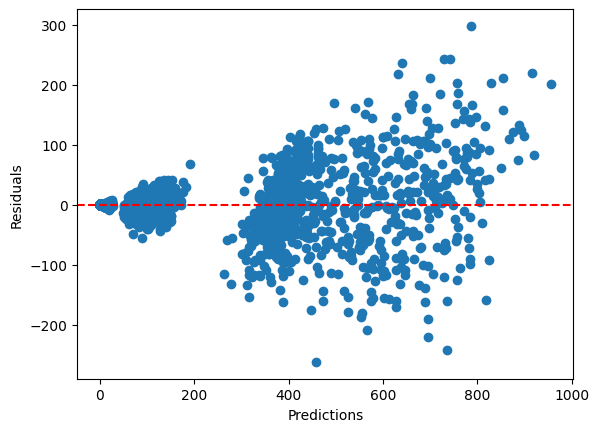

In [30]:
plot_residuals(y_test, y_pred)

### k-NN

In [31]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_test, y_pred)

MAE       22.964970
MSE     2070.493795
RMSE      45.502679
MAPE      11.195597
R2         0.961265
dtype: float64

### Random Forest

In [32]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_test, y_pred)

MAE       17.219442
MSE     1089.297122
RMSE      33.004502
MAPE       8.755128
R2         0.979622
dtype: float64

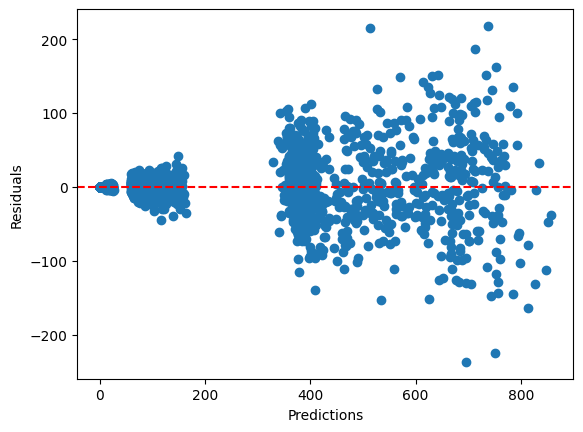

In [33]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()

### Gradient Boosting

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_test, y_pred)

MAE      16.743990
MSE     974.303388
RMSE     31.213833
MAPE     71.892506
R2        0.981773
dtype: float64

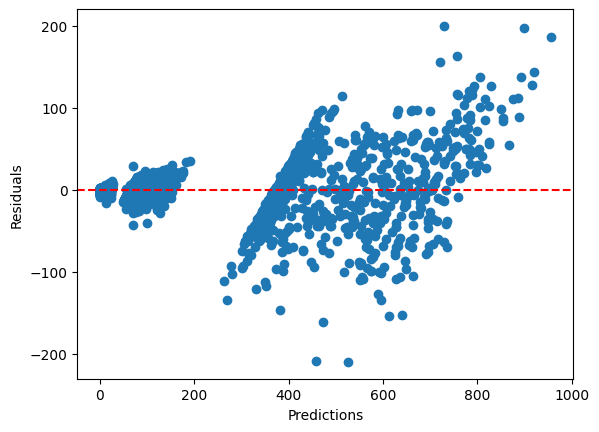

In [35]:
plot_residuals(y_test, y_pred)

### Rede Neural (MLP)

In [36]:
from sklearn.neural_network import MLPRegressor

In [37]:
model = MLPRegressor(hidden_layer_sizes=(50, 50), random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_test, y_pred)

MAE       22.808328
MSE     1521.506368
RMSE      39.006491
MAPE     161.455541
R2         0.971536
dtype: float64

In [38]:
model = MLPRegressor(hidden_layer_sizes=(25, 50, 75, 100), random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_test, y_pred)

MAE      16.703834
MSE     974.159423
RMSE     31.211527
MAPE     41.204475
R2        0.981776
dtype: float64

### Comparando os Modelos

In [39]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "k-NN": KNeighborsRegressor(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "MLP (Neural Network)": MLPRegressor(random_state=42)
}

In [40]:
from sklearn.model_selection import cross_val_score

In [41]:
results = {}

for model_name, model in models.items():
  print(f"Processing model: {model_name}")
  cv_results = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
  results[model_name] = {
      "Mean MAE": np.mean(-cv_results),
      "Std MAE": np.std(-cv_results)
  }

df_results = pd.DataFrame(results)

Processing model: Linear Regression
Processing model: Decision Tree
Processing model: k-NN
Processing model: Random Forest
Processing model: Gradient Boosting
Processing model: MLP (Neural Network)


In [42]:
df_results.T

,Mean MAE,Std MAE
Linear Regression,48.329511,0.839269
Decision Tree,23.417588,1.108291
k-NN,22.980543,0.992769
Random Forest,17.368041,0.595204
Gradient Boosting,16.429401,0.577899
MLP (Neural Network),30.761131,6.379189


<Axes: >

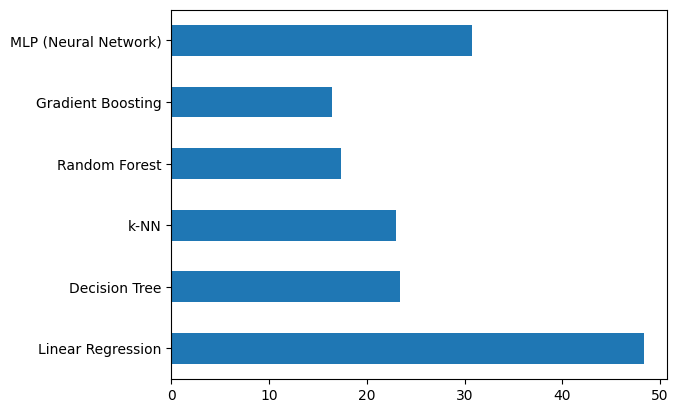

In [43]:
df_results.T["Mean MAE"].plot(kind="barh")

In [44]:
from sklearn.model_selection import KFold

In [45]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,Modelo,Ano de produção,Número de motores,Tipo de motor,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Região de Vendas
123,Airbus A350,1988,2,Turbofan,350,14800,9.45,4777.73,35,Avustralya
7033,Boeing 737,1986,2,Turbofan,162,5700,3.43,516.27,37,Güney Amerika
1952,Boeing 777,2017,2,Turbofan,396,15600,13.86,4709.85,6,Avustralya
10599,Airbus A320,1982,2,Turbofan,180,6300,3.42,2721.65,41,Avrupa
6131,Bombardier CRJ200,1989,2,Turbofan,50,3000,6.16,1974.45,34,Avrupa


In [47]:
for train_index, test_index in kfold.split(X_train):
  X_train_fold = X_train.iloc[train_index]
  X_test_fold = X_train.iloc[test_index]

  print("TRAIN:", train_index)
  print("TEST:", test_index)
  print("##############")

  # ...
  # pré-processamento, treinamento e avaliacao...

TRAIN: [   1    2    4 ... 9896 9898 9900]
TEST: [   0    3    8 ... 9894 9897 9899]
##############
TRAIN: [   0    1    2 ... 9897 9898 9899]
TEST: [  26   27   41 ... 9857 9863 9900]
##############
TRAIN: [   0    1    3 ... 9898 9899 9900]
TEST: [   2   15   28 ... 9881 9886 9896]
##############
TRAIN: [   0    1    2 ... 9898 9899 9900]
TEST: [   6    7   16 ... 9892 9893 9895]
##############
TRAIN: [   0    2    3 ... 9897 9899 9900]
TEST: [   1    4    5 ... 9888 9889 9898]
##############


## Impacto do Pré-processamento

### Encoding

In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
categorical_features

['Modelo', 'Tipo de motor', 'Região de Vendas']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[categorical_features])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [51]:
X_train_categorical_features = encoder.transform(X_train[categorical_features])
X_test_categorical_features = encoder.transform(X_test[categorical_features])

X_train = pd.concat([X_train.drop(categorical_features, axis=1), X_train_categorical_features], axis=1)
X_test = pd.concat([X_test.drop(categorical_features, axis=1), X_test_categorical_features], axis=1)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_test, y_pred)

MAE       23.093169
MSE     1970.238594
RMSE      44.387370
MAPE      11.671136
R2         0.963141
dtype: float64

In [52]:
from sklearn.preprocessing import LabelEncoder

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for column in categorical_features:
  encoder = LabelEncoder()
  encoder.fit(X_train[column])

  X_train[column] = encoder.transform(X_train[column])
  X_test[column] = encoder.transform(X_test[column])

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
regression_report(y_test, y_pred)

MAE       23.328621
MSE     2039.802692
RMSE      45.164175
MAPE      11.754954
R2         0.961840
dtype: float64

### Normalização

In [53]:
# Como a maioria dos modelos nao suportam dados categóricos,
# vamos aplicar o mesmo tratamento feito anteriormente, o One Hot Encoder.
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[categorical_features])

X_train_categorical_columns = encoder.transform(X_train[categorical_features])
X_test_categorical_columns = encoder.transform(X_test[categorical_features])

X_train = pd.concat([X_train.drop(categorical_features, axis=1), X_train_categorical_columns], axis=1)
X_test = pd.concat([X_test.drop(categorical_features, axis=1), X_test_categorical_columns], axis=1)

In [54]:
# k-NN com dados originais, sem normalizacao

model = KNeighborsRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
regression_report(y_test, y_pred)

MAE       22.964970
MSE     2070.493795
RMSE      45.502679
MAPE      11.195597
R2         0.961265
dtype: float64

In [55]:
# Visualizaçao dos dados com diferentes escalas
X_train.head()

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_0,Modelo_1,Modelo_2,...,Modelo_4,Modelo_5,Tipo de motor_0,Tipo de motor_1,Região de Vendas_0,Região de Vendas_1,Região de Vendas_2,Região de Vendas_3,Região de Vendas_4,Região de Vendas_5
123,1988,2,350,14800,9.45,4777.73,35,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,1986,2,162,5700,3.43,516.27,37,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,2017,2,396,15600,13.86,4709.85,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,1982,2,180,6300,3.42,2721.65,41,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,1989,2,50,3000,6.16,1974.45,34,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [56]:
# Transformacao das variáveis numéricas com MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_normalized = scaler.transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [57]:
X_train_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)
X_test_normalized = pd.DataFrame(X_test_normalized, columns=X_train.columns)

In [58]:
# Treinando e avaliando um k-NN com dados normalizados
model = KNeighborsRegressor()
model.fit(X_train_normalized, y_train)

y_pred = model.predict(X_test_normalized)

regression_report(y_test, y_pred)

MAE       18.008369
MSE     1180.904998
RMSE      34.364298
MAPE       9.168854
R2         0.977908
dtype: float64

In [59]:
# Treinando e avaliando um MLP com dados normalizados

model = MLPRegressor(hidden_layer_sizes=(50, 50), random_state=42)
model.fit(X_train_normalized, y_train)

y_pred = model.predict(X_test_normalized)

regression_report(y_test, y_pred)

MAE      16.655596
MSE     970.011631
RMSE     31.145010
MAPE     44.694438
R2        0.981853
dtype: float64

In [ ]:
model = MLPRegressor(hidden_layer_sizes=(25, 50, 75, 100), random_state=42)
model.fit(X_train_normalized, y_train)

y_pred = model.predict(X_test_normalized)

regression_report(y_test, y_pred)

MAE       16.861230
MSE     1014.597580
RMSE      31.852748
MAPE      37.954991
R2         0.981019
dtype: float64

In [62]:
model = MLPRegressor(hidden_layer_sizes=(100, 200), random_state=42)
model.fit(X_train_normalized, y_train)

y_pred = model.predict(X_test_normalized)

regression_report(y_test, y_pred)

MAE      16.515030
MSE     971.866594
RMSE     31.174775
MAPE     18.580425
R2        0.981818
dtype: float64

## Criação de Pipeline

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [64]:
categorical_features

['Modelo', 'Tipo de motor', 'Região de Vendas']

In [ ]:
numerical_features = X.select_dtypes("number").columns.tolist()
numerical_features

['Ano de produção',
 'Número de motores',
 'Capacidade',
 'Autonomia (km)',
 'Consumo de combustível (L/hora)',
 'Custo de manutenção por hora ($)',
 'Idade']

In [66]:
from sklearn import set_config
set_config(transform_output="pandas")

In [67]:
numerical_transformer = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

pipeline

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
preprocessor.fit_transform(X_train)

,numerical__Ano de produção,numerical__Número de motores,numerical__Capacidade,numerical__Autonomia (km),numerical__Consumo de combustível (L/hora),numerical__Custo de manutenção por hora ($),numerical__Idade,categorical__Modelo_Airbus A320,categorical__Modelo_Airbus A350,categorical__Modelo_Boeing 737,...,categorical__Modelo_Bombardier CRJ200,categorical__Modelo_Cessna 172,categorical__Tipo de motor_Piston,categorical__Tipo de motor_Turbofan,categorical__Região de Vendas_Afrika,categorical__Região de Vendas_Asya,categorical__Região de Vendas_Avrupa,categorical__Região de Vendas_Avustralya,categorical__Região de Vendas_Güney Amerika,categorical__Região de Vendas_Kuzey Amerika
123,0.186047,1.0,0.882653,0.944115,0.155305,0.950729,0.813953,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,0.139535,1.0,0.403061,0.308418,0.029810,0.003612,0.860465,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,0.860465,1.0,1.000000,1.000000,0.247238,0.935643,0.139535,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,0.046512,1.0,0.448980,0.350332,0.029602,0.493761,0.953488,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,0.209302,1.0,0.117347,0.119804,0.086721,0.327695,0.790698,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,0.302326,1.0,0.882653,0.944115,0.250573,0.445095,0.697674,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
5191,0.116279,0.0,0.000000,0.000000,0.335210,0.162766,0.883721,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5390,0.139535,1.0,0.117347,0.119804,0.137378,0.124172,0.860465,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
860,0.906977,1.0,1.000000,1.000000,0.025849,0.728955,0.093023,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [69]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
y_pred = pipeline.predict(X_test)

In [71]:
regression_report(y_test, y_pred)

MAE      16.744993
MSE     974.442567
RMSE     31.216063
MAPE     71.892673
R2        0.981770
dtype: float64